In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
def load_direct_data(en, cont, alg, name):
    path = f"./Data/generation_ex/{en}/{cont}/{alg}/{name}"
    json_files = list(Path(path).glob("*.json"))
    print(f"Found {len(json_files)} files!")
    with open(json_files[0], "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def extract_fitness_values(file_content):
    df = pd.DataFrame(file_content["fitness"]).reset_index(names="seed").melt(
        id_vars="seed", 
        var_name="ng", 
        value_name="population"
    )
    df["ng"] = df["ng"].astype(int)
    df["max_fit"] = df["population"].apply(lambda x: np.max(list(map(lambda y: y[0], x))))
    df["avg_fit"] = df["population"].apply(lambda x: np.mean(list(map(lambda y: y[0], x))))
    df["median_fit"] = df["population"].apply(lambda x: np.median(list(map(lambda y: y[0], x))))
    df["min_fit"] = df["population"].apply(lambda x: np.min(list(map(lambda y: y[0], x))))
    df["std_fit"] = df["population"].apply(lambda x: np.std(list(map(lambda y: y[0], x))))
    return df
def save_final_hyperparameters(en, cont, alg, hyper_paramters):
    
    with open("relevant_finals.json", "r+", encoding="utf-8") as f:
        try:
            data = json.load(f)
        except json.JSONDecodeError:
            data = {}

        f.seek(0)       
        if cont not in data:
            data[cont] = {}
        if en not in data[cont]:
            data[cont][en] = {}
        data[cont][en][alg] = hyper_paramters
        json.dump(data, f)
        f.truncate()

def get_decided():
    with open("relevant_finals.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        df = pd.json_normalize(data)
    return df.columns


In [ ]:
en = "lunarlander"
cont = "novelty_limit"
alg = "diff"
file_content = load_direct_data(en, cont, alg, "fourth_try")
df = extract_fitness_values(file_content)

Found 1 files!


In [ ]:


df

,seed,ng,population,max_fit,avg_fit,median_fit,min_fit,std_fit
0,105,50,"[[[-254.344669262425], [-0.18808752298355103, ...",59.834650,-160.156559,-139.421467,-457.254820,101.944635
1,104,50,"[[[-140.0606383206331], [-0.21383352279663087,...",83.626081,-138.869524,-140.671988,-380.713579,71.240666
2,103,50,"[[[-232.3678386885271], [0.4065817356109619, 0...",0.381870,-144.781547,-133.459446,-395.925750,83.610742
3,102,50,"[[[-12.58084903320887], [0.1920881986618042, -...",12.880675,-162.501056,-150.630424,-515.377260,105.041451
4,101,50,"[[[-103.34909302029546], [0.02463192045688629,...",-23.236520,-184.051936,-145.356842,-472.480628,105.404988
5,105,25,"[[[-145.251570752934], [0.11948719024658203, -...",-38.716319,-181.567944,-168.775125,-457.254820,89.841891
6,104,25,"[[[-80.98142505566749], [0.008844222873449326,...",83.626081,-134.186732,-139.544411,-233.522370,60.866243
7,103,25,"[[[-119.15238249028066], [-0.02137428224086761...",0.381870,-178.364454,-149.888502,-519.464619,101.738796
8,102,25,"[[[-218.7829181606788], [0.07142173647880554, ...",54.914624,-172.448111,-150.639999,-515.377260,102.391004
9,101,25,"[[[-103.34909302029546], [0.02463192045688629,...",-23.236520,-177.527750,-145.356842,-401.874861,90.734724


<Axes: xlabel='ng', ylabel='value'>

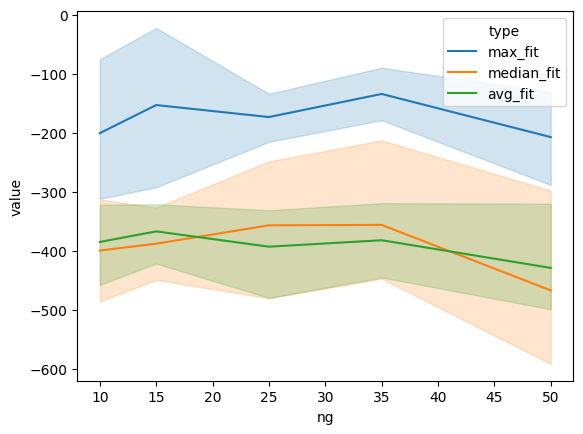

In [ ]:
import seaborn as sns
df = df.sort_values("ng")
ploted_df = df[["ng", "seed", "max_fit", "median_fit", "avg_fit"]]
#ploted_df = ploted_df.groupby("ng").mean().reset_index()
if "seed" in ploted_df.columns:
    ploted_df = ploted_df.drop(columns="seed")
ploted_df = ploted_df.melt(
        id_vars="ng", 
        var_name="type", 
        value_name="value"
    )
sns.lineplot(data=ploted_df, x="ng", y="value", hue="type")

In [ ]:
file_content["arguments"]

{'l': 50,
 'mr': 0.8,
 'cr': 0.8,
 'archiving_period': 2,
 'archive_batch': 1,
 'limit': -180.0}

In [ ]:
get_decided()

In [ ]:
DECIDED_NG_VALUE = 35
args = file_content["arguments"]
args["ng"] = DECIDED_NG_VALUE
save_final_hyperparameters(en, cont, alg, args)